In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)
import time
import pickle
from torch.autograd import Variable

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [31]:
transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

P_transform = transforms.Compose([
    transforms.ToTensor()
])

preview = datasets.CIFAR10(root='./data', train=False, download=True, transform=P_transform)
class_names = preview.classes

dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


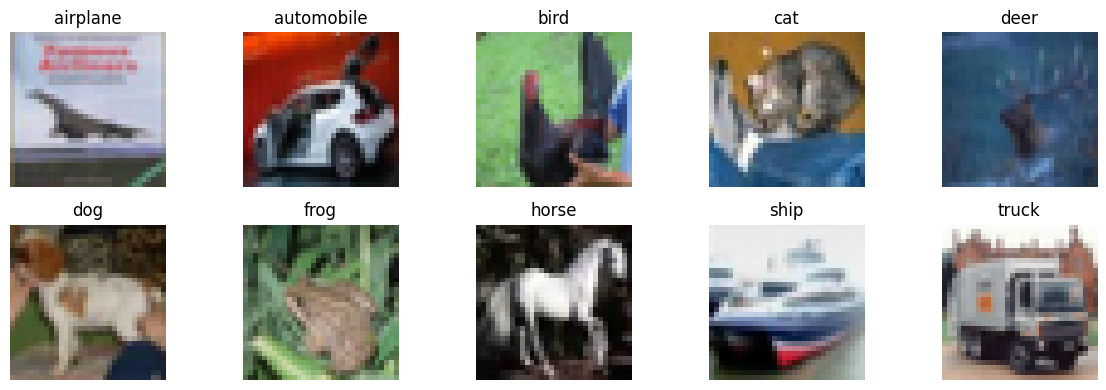

In [32]:
label_to_image = {}

for img, label in preview:
    if label not in label_to_image:
        label_to_image[label] = img
    if len(label_to_image) == 10:
        break

# Plot the images
plt.figure(figsize=(12, 4))
for i in range(10):
    img = label_to_image[i]
    img = img.permute(1, 2, 0)
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(class_names[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [33]:
class InitialConv(nn.Module):
    def __init__(self, in_channels=3, out_channels=256, kernel_size=9):
        super(InitialConv, self).__init__()
        self.conv_layer = nn.Conv2d(in_channels, out_channels, kernel_size, stride=1)

    def forward(self, x):
        return F.relu(self.conv_layer(x))

In [34]:
class PrimaryCapsules(nn.Module):
    def __init__(self, capsule_dim=8, in_channels=256, capsule_channels=32, kernel_size=9, num_routes=32 * 6 * 6):
        super(PrimaryCapsules, self).__init__()
        self.num_routes = num_routes
        self.capsule_layers = nn.ModuleList([
            nn.Conv2d(in_channels, capsule_channels, kernel_size=kernel_size, stride=2, padding=0)
            for _ in range(capsule_dim)])

    def forward(self, x):
        u = [layer(x) for layer in self.capsule_layers]
        u = torch.stack(u, dim=1)
        u = u.view(x.size(0), self.num_routes, -1)
        return self.squash(u)

    def squash(self, tensor):
        norm = (tensor ** 2).sum(-1, keepdim=True)
        return (norm * tensor) / ((1.0 + norm) * torch.sqrt(norm + 1e-8))

In [35]:
class DigitCapsules(nn.Module):
    def __init__(self, num_classes=10, num_routes=32 * 6 * 6, in_dim=8, out_dim=16):
        super(DigitCapsules, self).__init__()
        self.W = nn.Parameter(torch.randn(1, num_routes, num_classes, out_dim, in_dim))
        self.num_classes = num_classes
        self.num_routes = num_routes

    def forward(self, x):
        batch_size = x.size(0)
        x = torch.stack([x] * self.num_classes, dim=2).unsqueeze(4)
        
        W = torch.cat([self.W] * batch_size, dim=0)
        u_hat = torch.matmul(W, x)

        b_ij = Variable(torch.zeros(1, self.num_routes, self.num_classes, 1)).cuda()
        
        num_iterations = 3
        for iteration in range(num_iterations):
            c_ij = F.softmax(b_ij, dim=1)
            c_ij = torch.cat([c_ij] * batch_size, dim=0).unsqueeze(4)

            s_j = (c_ij * u_hat).sum(dim=1, keepdim=True)
            v_j = self.squash(s_j)

            if iteration < num_iterations - 1:
                a_ij = torch.matmul(u_hat.transpose(3, 4), torch.cat([v_j] * self.num_routes, dim=1))
                b_ij = b_ij + a_ij.squeeze(4).mean(dim=0, keepdim=True)
                
        return v_j.squeeze(1)

    def squash(self, tensor):
        norm = (tensor ** 2).sum(-1, keepdim=True)
        return (norm * tensor) / ((1.0 + norm) * torch.sqrt(norm + 1e-8))

In [ ]:
class CapsuleDecoder(nn.Module):
    def __init__(self, img_width=28, img_height=28, img_channels=1):
        super(CapsuleDecoder, self).__init__()
        self.reconstruction = nn.Sequential(
            nn.Linear(16 * 10, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, img_width * img_height * img_channels),
            nn.Sigmoid()
        )

    def forward(self, digit_caps, input_img):
        class_probs = torch.sqrt((digit_caps ** 2).sum(2))
        class_probs = F.softmax(class_probs, dim=0)
        
        _, max_indices = class_probs.max(dim=1)
        mask = torch.eye(10, device=digit_caps.device)
        mask = mask.index_select(dim=0, index=max_indices.view(-1))
        masked_caps = (digit_caps * mask[:, :, None, None]).view(digit_caps.size(0), -1)
        recon = self.reconstruction(masked_caps)
        recon = recon.view(-1, input_img.size(1), input_img.size(2), input_img.size(3))
        return recon, mask

In [37]:
class CapsuleNetwork(nn.Module):
    def __init__(self, config=None):
        super(CapsuleNetwork, self).__init__()
        self.conv = InitialConv(3,256,9)
        self.primary_caps = PrimaryCapsules(8, 256, 32, 9, 32*8*8)
        self.digit_caps = DigitCapsules(10, 32*8*8, 8, 16)
        self.decoder = CapsuleDecoder(32, 32, 3)
        self.mse = nn.MSELoss()

    def forward(self, x):
        features = self.conv(x)
        primary_output = self.primary_caps(features)
        digit_output = self.digit_caps(primary_output)
        recon, mask = self.decoder(digit_output, x)
        return digit_output, recon, mask

    def loss(self, original, digit_output, labels, reconstruction):
        return self.margin_loss(digit_output, labels) + self.reconstruction_loss(original, reconstruction)

    def margin_loss(self, x, labels):
        batch_size = x.size(0)
        lengths = torch.sqrt((x ** 2).sum(dim=2, keepdim=True))
        left = F.relu(0.9 - lengths).view(batch_size, -1)
        right = F.relu(lengths - 0.1).view(batch_size, -1)
        loss = labels * left + 0.5 * (1.0 - labels) * right
        return loss.sum(dim=1).mean()

    def reconstruction_loss(self, original, reconstruction):
        return self.mse(reconstruction.view(reconstruction.size(0), -1), original.view(reconstruction.size(0), -1)) * 0.0005

In [38]:
def train_and_validate(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    device: torch.device,
    num_epochs: int,
    optimizer: torch.optim.Optimizer,
    early_stopping: int = None,
):
    train_losses, train_accuracies = [], []
    validation_losses, validation_accuracies = [], []
    epoch_times = []
    best_val_accuracy = 0.0
    epochs_without_improvement, train_predicted_true = 0,0
    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        model.train()

        train_loss, train_predicted_true, correct_train, total_train = 0.0, 0, 0, 0

        for inputs, labels in train_loader:
            one_hot_targets = F.one_hot(labels, num_classes=10).float().to(device)
            inputs, one_hot_targets = inputs.to(device), one_hot_targets.to(device)
            
            optimizer.zero_grad()
            outputs, reconstructions, masked = model(inputs)
            loss = model.loss(inputs, outputs, one_hot_targets, reconstructions)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            predicted = masked.argmax(dim=1)
            train_predicted_true += predicted.eq(one_hot_targets.argmax(dim=1)).sum().item()
            total_train += labels.size(0)

        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_predicted_true / total_train)

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        for inputs, labels in val_loader:
            one_hot_targets = F.one_hot(labels, num_classes=10).float()
            inputs, one_hot_targets = inputs.to(device), one_hot_targets.to(device)
                
            optimizer.zero_grad()
            outputs, reconstructions, masked = model(inputs)
            loss = model.loss(inputs, outputs, one_hot_targets, reconstructions)
            loss.backward()
            optimizer.step()

            val_loss += loss.item()
            predicted = masked.argmax(dim=1)
            correct_val += predicted.eq(one_hot_targets.argmax(dim=1)).sum().item()
            total_val += labels.size(0)

        val_loss_epoch = val_loss / len(val_loader)
        val_acc_epoch = correct_val / total_val
        validation_losses.append(val_loss_epoch)
        validation_accuracies.append(val_acc_epoch)

        if val_acc_epoch > best_val_accuracy:
            best_val_accuracy = val_acc_epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if early_stopping and epochs_without_improvement >= early_stopping:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1}/{num_epochs} - Time: {epoch_time:.2f} sec")
        print(f"Training Loss: {train_losses[-1]:.4f}, Training Accuracy: {train_accuracies[-1]:.4f}")
        print(f"Validation Loss: {validation_losses[-1]:.4f},Validation Accuracy: {validation_accuracies[-1]:.4f}")

    total_time = time.time() - start_time
    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    print(f"\nTotal Training Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
    print(f"Average Time per Epoch: {avg_epoch_time:.2f} seconds")

    return train_losses, train_accuracies, validation_losses, validation_accuracies

In [39]:
def test_model(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, device: torch.device) -> tuple:
    model.eval()
    test_loss, correct_test = 0.0, 0
    test_predictions, labels_test_total, test_probabilities = [], [], []

    for inputs, labels in dataloader:
            one_hot_targets = F.one_hot(labels, num_classes=10).float()
            inputs, one_hot_targets = inputs.to(device), one_hot_targets.to(device)
                
            optimizer.zero_grad()
            outputs, reconstructions, masked = model(inputs)
            loss = model.loss(inputs, outputs, one_hot_targets, reconstructions)
            loss.backward()
            optimizer.step()
            
            test_loss += loss.item()
            probs = masked
            predicted = masked.argmax(dim=1)

            correct_test += predicted.eq(one_hot_targets.argmax(dim=1)).sum().item()
            test_predictions.extend(predicted.tolist())
            labels_test_total.extend(one_hot_targets.tolist())
            test_probabilities.extend(probs.tolist())

    test_loss /= len(dataloader)
    test_accuracy = 100 * correct_test / len(dataloader.dataset)

    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")

    return test_loss, test_accuracy

In [40]:
def plot_metric_curve(train_values, val_values, test_value, xlabel, ylabel, title, legend_labels):
    plt.figure(figsize=(12, 5))
    plt.plot(train_values, label=legend_labels[0])
    plt.plot(val_values, label=legend_labels[1])
    plt.axhline(y=test_value, color='r', linestyle='--', label=legend_labels[2])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [41]:
def convert_to_numpy(tensor):
    return tensor.cpu().numpy() if isinstance(tensor, torch.Tensor) else np.array(tensor)

def metrics(
    test_loss, test_accuracy, train_losses, train_accuracies, validation_losses, validation_accuracies
):
    print(f"Accuracy: {test_accuracy:.4f}")

    plot_metric_curve(train_losses, validation_losses, test_loss,
                      xlabel='Epoch', ylabel='Loss', title='Loss Curve',
                      legend_labels=['Training Loss', 'Validation Loss', 'Test Loss'])

    plot_metric_curve( train_accuracies, validation_accuracies, test_accuracy,
                      xlabel='Epoch', ylabel='Accuracy', title='Accuracy Curve',
                      legend_labels=['Train Accuracy', 'Validation Accuracy', 'Final Test Accuracy'])

In [54]:
def display_misclassified_images(model, test_loader, device, class_names, num_images=5):

    model.eval()
    misclassified_images = []
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            one_hot_targets = F.one_hot(labels, num_classes=10).float()
            inputs, one_hot_targets = inputs.to(device), one_hot_targets.to(device)
            outputs, reconstructions, masked = model(inputs)
            preds = masked.argmax(dim=1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified_images.append(inputs[i].cpu())
                    true_labels.append(labels[i].cpu().item())
                    predicted_labels.append(preds[i].cpu().item())

                if len(misclassified_images) >= num_images:
                    break
            if len(misclassified_images) >= num_images:
                break

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i in range(num_images):
        img = misclassified_images[i].permute(1, 2, 0).numpy()
        true_label = class_names[true_labels[i]]
        pred_label = class_names[predicted_labels[i]]

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=10, color='red')
        axes[i].axis("off")

    plt.show()

In [43]:
model = CapsuleNetwork().to(device)
print(model)

CapsuleNetwork(
  (conv): InitialConv(
    (conv_layer): Conv2d(3, 256, kernel_size=(9, 9), stride=(1, 1))
  )
  (primary_caps): PrimaryCapsules(
    (capsule_layers): ModuleList(
      (0-7): 8 x Conv2d(256, 32, kernel_size=(9, 9), stride=(2, 2))
    )
  )
  (digit_caps): DigitCapsules()
  (decoder): CapsuleDecoder(
    (reconstruction): Sequential(
      (0): Linear(in_features=160, out_features=512, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=512, out_features=1024, bias=True)
      (3): ReLU(inplace=True)
      (4): Linear(in_features=1024, out_features=3072, bias=True)
      (5): Sigmoid()
    )
  )
  (mse): MSELoss()
)


In [44]:
model.load_state_dict(torch.load("/kaggle/working/model.pt"))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses, train_accuracies, validation_losses, validation_accuracies = train_and_validate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    optimizer = optimizer,
    num_epochs = 10)

torch.save(model.state_dict(),"/kaggle/working/model.pt")
print("Model saved successfully!")

Epoch 1/10 - Time: 205.14 sec
Training Loss: 0.2205, Training Accuracy: 0.9229
Validation Loss: 0.2115,Validation Accuracy: 0.9269
Epoch 2/10 - Time: 205.04 sec
Training Loss: 0.1881, Training Accuracy: 0.9403
Validation Loss: 0.1794,Validation Accuracy: 0.9403
Epoch 3/10 - Time: 204.37 sec
Training Loss: 0.1733, Training Accuracy: 0.9480
Validation Loss: 0.1599,Validation Accuracy: 0.9498
Epoch 4/10 - Time: 204.65 sec
Training Loss: 0.1621, Training Accuracy: 0.9549
Validation Loss: 0.1445,Validation Accuracy: 0.9577
Epoch 5/10 - Time: 204.55 sec
Training Loss: 0.1520, Training Accuracy: 0.9588
Validation Loss: 0.1316,Validation Accuracy: 0.9642
Epoch 6/10 - Time: 204.48 sec
Training Loss: 0.1447, Training Accuracy: 0.9650
Validation Loss: 0.1196,Validation Accuracy: 0.9687
Epoch 7/10 - Time: 205.12 sec
Training Loss: 0.1367, Training Accuracy: 0.9682
Validation Loss: 0.1095,Validation Accuracy: 0.9732
Epoch 8/10 - Time: 204.92 sec
Training Loss: 0.1290, Training Accuracy: 0.9727
Vali

In [45]:
#model.load_state_dict(torch.load("/kaggle/working/model.pt"))
test_loss, test_accuracy = test_model(model,test_loader,device)

Test Accuracy: 96.46%
Test Loss: 0.1251


In [46]:
model_values = {
    "test_loss": test_loss,
    "train_losses": train_losses,
    "train_accuracies": train_accuracies,
    "validation_losses": validation_losses,
    "validation_accuracies": validation_accuracies
}

with open("/kaggle/working/model_values.pkl", "wb") as f:
    pickle.dump(model_values, f)
print("Variables saved successfully!")

Variables saved successfully!


Accuracy: 0.9646


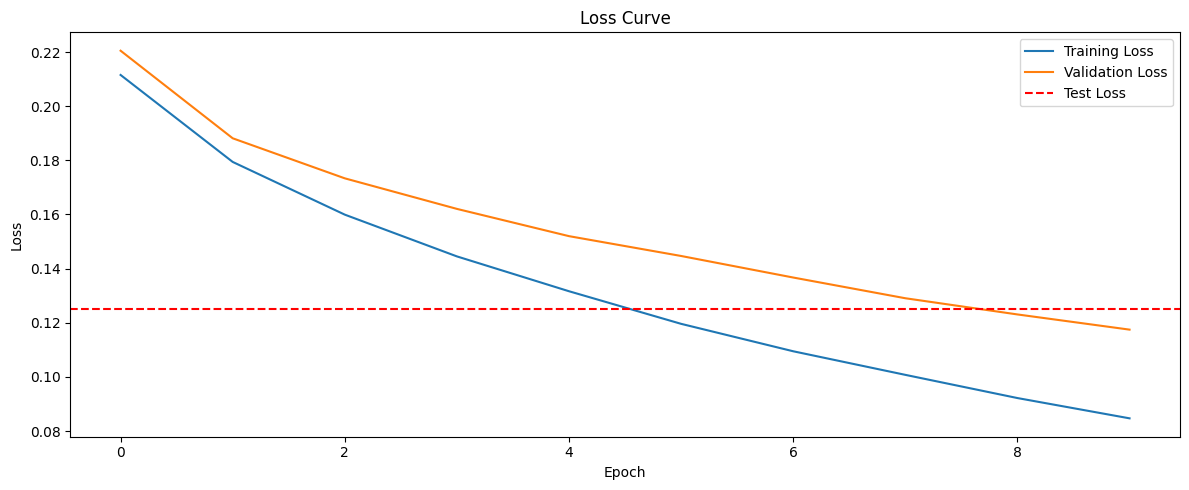

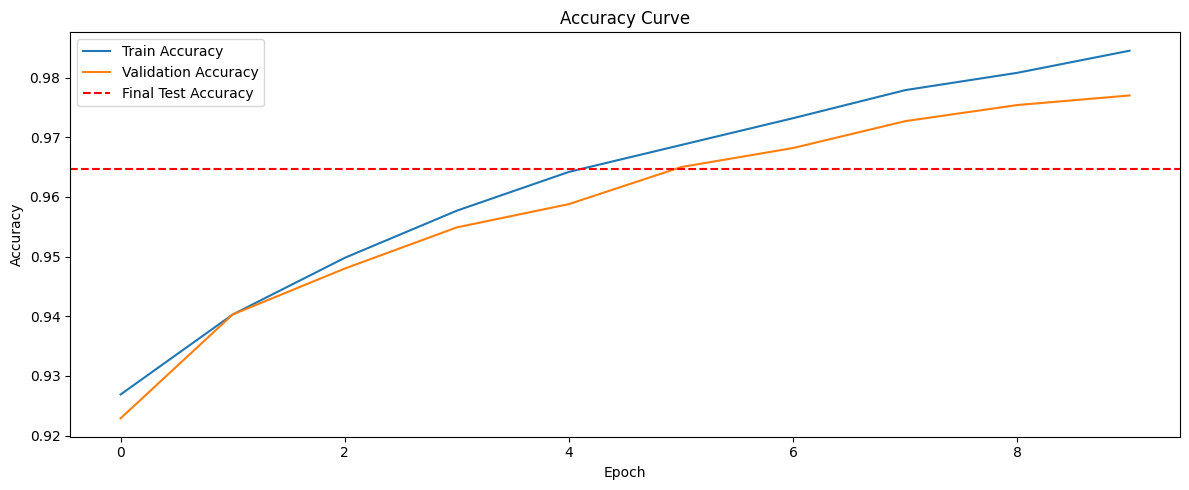

In [ ]:
with open("model_values.pkl", "rb") as f:
    loaded_data = pickle.load(f)

test_loss = loaded_data["test_loss"]
train_losses = loaded_data["train_losses"]
train_accuracies = loaded_data["train_accuracies"]
validation_losses = loaded_data["validation_losses"]
validation_accuracies = loaded_data["validation_accuracies"]

metrics(test_loss, test_accuracy, train_losses,  train_accuracies, validation_losses, validation_accuracies)

Misclassified Images: 


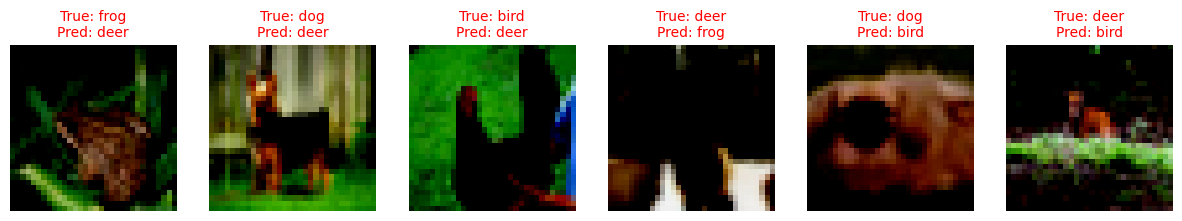

In [57]:
class_names = ['airplane', 'automobile', 'bird',  'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("Misclassified Images: ")
display_misclassified_images(model, test_loader, device, class_names, num_images=6)